In [15]:
import pandas as pd
import tushare as ts
import numpy as np
import time
import matplotlib.pyplot as plt

pro = ts.pro_api('b7bf12884a6ba2a5b33717fea342a6e8d3ab2fa80b5bb8ff6682e20f')
df = pro.index_weight(index_code='000300.SH', start_date='20230101', end_date='20251231')

hs300_code_list = df['con_code'].drop_duplicates().to_list()
dict_stock = {}
code = hs300_code_list[0]
hs300_daily = pro.daily(ts_code=str(code), start_date='20230101', end_date='20251231', fields='ts_code,trade_date,open,close')
hs300_daily['ma5'] = hs300_daily['close'].rolling(window=5).mean()
hs300_daily['ma20'] = hs300_daily['close'].rolling(window=20).mean()
signal = pd.Series(np.where((hs300_daily['ma5'] - hs300_daily['ma20'])>0, 1, 0))
cross = signal.diff().fillna(0)
hs300_daily['cross'] = cross
if hs300_daily.empty:
    print('fail!')
dict_stock[code] = hs300_daily
print(dict_stock[code])
df1 = dict_stock[code]
df2 = df1[df1['cross']==1]['cross']
print(df2.sum())

       ts_code trade_date    open   close      ma5      ma20  cross
0    300750.SZ   20251231  369.79  367.26      NaN       NaN    0.0
1    300750.SZ   20251230  367.10  369.20      NaN       NaN    0.0
2    300750.SZ   20251229  374.00  369.31      NaN       NaN    0.0
3    300750.SZ   20251226  372.96  374.43      NaN       NaN    0.0
4    300750.SZ   20251225  374.21  373.01  370.642       NaN    0.0
..         ...        ...     ...     ...      ...       ...    ...
722  300750.SZ   20230109  422.88  416.60  429.892  448.4385    0.0
723  300750.SZ   20230106  406.00  416.66  425.324  446.9740    0.0
724  300750.SZ   20230105  388.00  407.51  420.126  444.7000    0.0
725  300750.SZ   20230104  386.50  384.01  411.356  441.5400    0.0
726  300750.SZ   20230103  392.00  389.64  402.884  438.6170    0.0

[727 rows x 7 columns]
23.0


dict_stock is ready!
2024-01-01 00:00:00
DatetimeIndex(['2025-12-31', '2025-12-30', '2025-12-29', '2025-12-26',
               '2025-12-25', '2025-12-24', '2025-12-23', '2025-12-22',
               '2025-12-19', '2025-12-18',
               ...
               '2023-01-16', '2023-01-13', '2023-01-12', '2023-01-11',
               '2023-01-10', '2023-01-09', '2023-01-06', '2023-01-05',
               '2023-01-04', '2023-01-03'],
              dtype='datetime64[us]', name='trade_date', length=727, freq=None)
DatetimeIndex(['2025-12-31', '2025-12-30', '2025-12-29', '2025-12-26',
               '2025-12-25', '2025-12-24', '2025-12-23', '2025-12-22',
               '2025-12-19', '2025-12-18',
               ...
               '2023-01-16', '2023-01-13', '2023-01-12', '2023-01-11',
               '2023-01-10', '2023-01-09', '2023-01-06', '2023-01-05',
               '2023-01-04', '2023-01-03'],
              dtype='datetime64[us]', name='trade_date', length=727, freq=None)
DatetimeIndex(['202

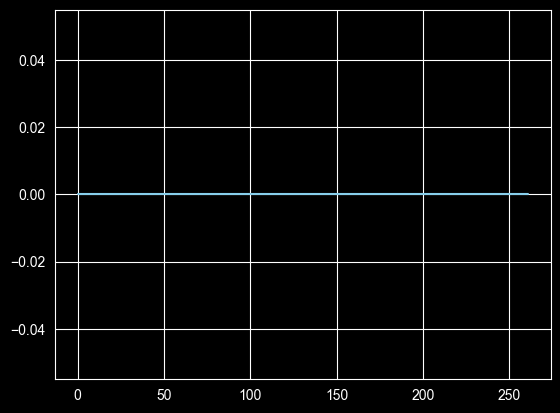

In [9]:
import pandas as pd
import tushare as ts
import numpy as np
import time
from datetime import datetime

pro = ts.pro_api('b7bf12884a6ba2a5b33717fea342a6e8d3ab2fa80b5bb8ff6682e20f')
df = pro.index_weight(index_code='000300.SH', start_date='20230101', end_date='20251231')

hs300_code_list = df['con_code'].drop_duplicates().to_list()
dict_stock = {}
for code in hs300_code_list:
    hs300_daily = pro.daily(ts_code=str(code), start_date='20230101', end_date='20251231', fields='ts_code,trade_date,open,close')
    hs300_daily['trade_date'] = pd.to_datetime(hs300_daily['trade_date'], format='%Y%m%d')
    hs300_daily.set_index('trade_date', inplace=True)
    hs300_daily['ma5'] = hs300_daily['close'].rolling(window=5).mean()
    hs300_daily['ma20'] = hs300_daily['close'].rolling(window=20).mean()
    signal = pd.Series(np.where((hs300_daily['ma5'] - hs300_daily['ma20'])>0, 1, 0))
    cross = signal.diff().fillna(0)
    hs300_daily['cross'] = cross
    if hs300_daily.empty:
        print('fail!')
        break
    time.sleep(0.12)
    dict_stock[code] = hs300_daily
print('dict_stock is ready!')

sample = hs300_code_list[:5]
vol = 100  # 股

def calculate_return(buy_price, sell_price, volume=100):
    if len(buy_price) == 0 or len(sell_price) == 0:
        buy_price = None
        sell_price = None
    if len(buy_price) > len(sell_price):
        buy_price = buy_price[:len(sell_price)]
    elif len(buy_price) < len(sell_price):
        sell_price = sell_price[:len(buy_price)]
    ret = (sell_price - buy_price).sum() * volume
    return_ratio = ret / (buy_price.sum() * volume)
    return ret, return_ratio


def run_portfolio_strategy(time_begin,time_end,portfolio=sample):  # 含time_end 传入形式: '20240101'
    import matplotlib.pyplot as plt
    daily_value = []
    sery = pd.date_range(start=time_begin, end=time_end, freq='B', normalize=True)
    for time in sery:
        print(time)
        daily_delta = 0
        for code in portfolio:
            if time in dict_stock[code].index:
                print(1)
                df = dict_stock[code].loc[time]
                if df['cross'] ==1:  # 买入
                    daily_delta += df['close'] * vol
                    print(f"买入 {code} at {time}, price {df['close']}")
                elif df['cross'] == -1:  # 卖出
                    daily_delta -= df['close'] * vol
                    print(f"卖出 {code} at {time}, price {df['close']}")
        daily_value.append(daily_delta)
    line = np.cumsum(daily_value)
    plt.plot(line,color='skyblue')

run_portfolio_strategy('20240101','20241231',sample)


2024-01-01 00:00:00
2024-01-02 00:00:00
ts_code    300750.SZ
open          162.22
close         156.83
ma5          152.946
ma20        152.9505
cross            NaN
Name: 2024-01-02 00:00:00, dtype: object
ts_code    600519.SH
open          1715.0
close        1685.01
ma5         1671.072
ma20       1642.1055
cross            NaN
Name: 2024-01-02 00:00:00, dtype: object
ts_code    601318.SH
open            40.3
close          39.47
ma5           39.038
ma20         39.1655
cross            NaN
Name: 2024-01-02 00:00:00, dtype: object
ts_code    300308.SZ
open          112.85
close         110.61
ma5          103.686
ma20        106.1575
cross            NaN
Name: 2024-01-02 00:00:00, dtype: object
ts_code    601899.SH
open           12.41
close          12.49
ma5            12.46
ma20         12.1285
cross            NaN
Name: 2024-01-02 00:00:00, dtype: object
2024-01-03 00:00:00
ts_code    300750.SZ
open           156.1
close          155.8
ma5           151.32
ma20        152.1465


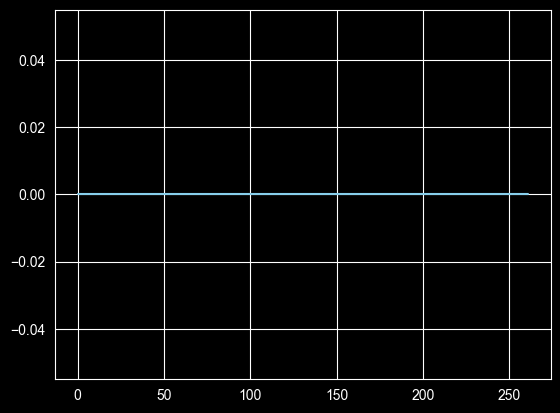

In [11]:
def run_portfolio_strategy(time_begin,time_end,portfolio=sample):  # 含time_end 传入形式: '20240101'
    import matplotlib.pyplot as plt
    daily_value = []
    sery = pd.date_range(start=time_begin, end=time_end, freq='B', normalize=True)
    for time in sery:
        print(time)
        vol=100
        daily_delta = 0
        for code in portfolio:
            if time in dict_stock[code].index:
                df = dict_stock[code].loc[time]
                print(df)
                if df['cross'] ==1:  # 买入
                    daily_delta += df['close'] * vol
                    print(f"买入 {code} at {time}, price {df['close']}")
                elif df['cross'] == -1:  # 卖出
                    daily_delta -= df['close'] * vol
                    print(f"卖出 {code} at {time}, price {df['close']}")
        daily_value.append(daily_delta)
    line = np.cumsum(daily_value)
    plt.plot(line,color='skyblue')

run_portfolio_strategy('20240101','20241231',sample)

In [2]:
import pandas as pd
pd.date_range('20000101','20000105')

DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-03', '2000-01-04',
               '2000-01-05'],
              dtype='datetime64[us]', freq='D')